<a href="https://colab.research.google.com/github/RyanChenJung/Airbnb-Renting-Optimizer/blob/main/notebooks/szuyu/clustering_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import umap

In [2]:
df = pd.read_csv('Chicago_Airbnb_Master_v5.csv')

In [3]:
df.head()

,Unnamed: 0,listing_id,price,accommodates,bedrooms,bathrooms,room_type,property_type,review_scores_rating,occupancy_proxy,...,topic_6,topic_7,location_quality,amenities_quality,parking,property_interior,sleep_comfort,overall_experience,accessibility,hotel_like_experience
0,0,2384,119.0,1,1.0,1.0,Private room,Private room in condo,4.99,0.046575,...,0.051686,0.003908,0.777278,0.390296,0.358335,0.294125,0.408060,0.558576,0.228655,0.304287
1,1,7126,89.0,2,1.0,1.0,Entire home/apt,Entire rental unit,4.73,0.172603,...,0.025036,0.386278,0.670910,0.582058,0.409550,0.349748,0.552666,0.600466,0.382934,0.262298
2,2,10945,203.0,4,2.0,1.0,Entire home/apt,Entire rental unit,4.74,0.109589,...,0.005006,0.005005,0.863403,0.523719,0.434791,0.577407,0.141774,0.512716,0.161578,0.298800
3,3,12140,339.0,3,1.0,1.0,Private room,Room in boutique hotel,4.95,0.572603,...,0.020880,0.347268,0.727978,1.000000,0.000000,0.478641,0.000000,0.268485,0.186604,0.220714
4,4,28749,258.0,6,3.0,2.0,Entire home/apt,Entire loft,4.83,0.797260,...,0.618390,0.003692,0.750634,0.540407,0.526085,0.492242,0.779488,0.563332,0.177117,0.177489


In [3]:
selected_features = [
    'price', 'accommodates',
    'estimated_annual_revenue', 'occupancy_proxy',
    'shoreline_gravity', 'distance_to_downtown_km',
    'avg_review_length', 'overall_experience',
    'hotel_like_experience', 'amenities_quality'
]

In [4]:
X = df[selected_features].copy()
X = X.fillna(X.median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Final_Integrated_Cluster'] = kmeans.fit_predict(X_scaled)

In [6]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, df['Final_Integrated_Cluster'])
print(f"silhouette scroe: {score}")

silhouette scroe: 0.16180640721384426


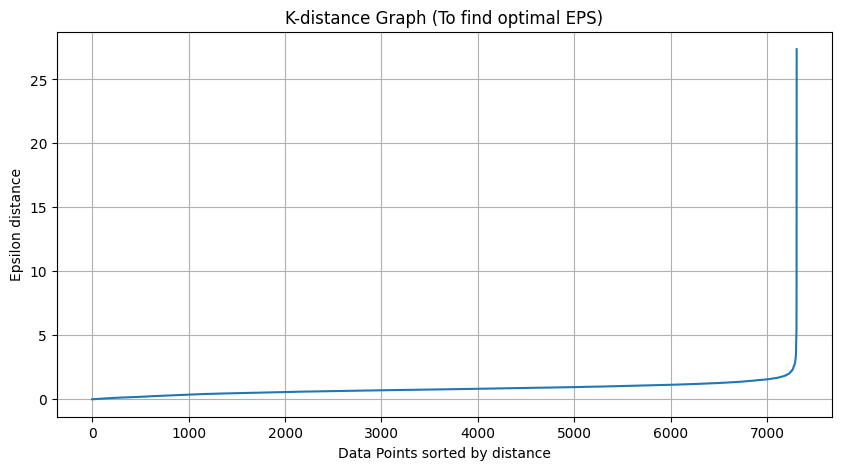

✅ 成功分出 5 個群體
⚠️ 標記了 3810 個離群值 (Noise points, Cluster -1)

--- 離群值 (Cluster -1) 的平均特徵 ---
price                         229.388714
accommodates                    5.313386
estimated_annual_revenue    26959.800525
occupancy_proxy                 0.403560
shoreline_gravity               0.431937
distance_to_downtown_km         7.892532
avg_review_length             248.501712
overall_experience              0.481238
hotel_like_experience           0.160499
amenities_quality               0.417403
dtype: float64

📊 排除噪點後的輪廓分數: -0.1490


In [7]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# 1. 尋找最佳 eps 參數 (K-distance Graph)
# DBSCAN 對 eps 非常敏感。我們通常觀察「第 k 個最近鄰居」的距離
# 規則：k 通常設為 特徵數 * 2 (這裡特徵有 8 個，所以設 16)
neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# 排序距離並畫圖
distances = np.sort(distances, axis=0)
distances = distances[:, 1]
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-distance Graph (To find optimal EPS)')
plt.xlabel('Data Points sorted by distance')
plt.ylabel('Epsilon distance')
plt.grid(True)
plt.show()

# 💡 指導：觀察曲線「最陡」的地方（轉折點），那個距離就是你的最佳 eps。
# 假設轉折點在 1.5 左右 (你可以根據圖表結果調整下方數值)

# 2. 執行 DBSCAN
# eps: 鄰域半徑
# min_samples: 成為核心點所需的最少鄰居數
dbscan = DBSCAN(eps=1.0, min_samples=10)
db_clusters = dbscan.fit_predict(X_scaled)

# 3. 將結果存回原 DataFrame
df['DBSCAN_Cluster'] = db_clusters

# 4. 檢查分群結果與噪點比例
n_clusters = len(set(db_clusters)) - (1 if -1 in db_clusters else 0)
n_noise = list(db_clusters).count(-1)

print(f"✅ 成功分出 {n_clusters} 個群體")
print(f"⚠️ 標記了 {n_noise} 個離群值 (Noise points, Cluster -1)")

# 5. 分析離群值 (Noise) 的特徵
if n_noise > 0:
    print("\n--- 離群值 (Cluster -1) 的平均特徵 ---")
    noise_profile = df[df['DBSCAN_Cluster'] == -1][selected_features].mean()
    print(noise_profile)

# 6. 計算輪廓分數 (排除噪點後計算)
if n_clusters > 1:
    mask = df['DBSCAN_Cluster'] != -1
    score = silhouette_score(X_scaled[mask], df.loc[mask, 'DBSCAN_Cluster'])
    print(f"\n📊 排除噪點後的輪廓分數: {score:.4f}")

In [8]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

# 1. 定義搜尋範圍
# eps: 建議從 0.1 到 2.0 之間細分（因為資料已經過標準化）
eps_range = np.arange(0.5, 2.1, 0.1)
# min_samples: 通常設為 特徵數(8) 到 特徵數*3 之間
min_samples_range = range(5, 21, 5)

results = []

print("🔍 Starting Grid Search for DBSCAN...")

for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)

        # 取得分群統計
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)

        # 只有在分群大於 1 且 噪點比例不過高(例如 < 50%) 的情況下計算分數
        if n_clusters > 1 and noise_ratio < 0.5:
            # 排除噪點計算 Silhouette Score
            mask = labels != -1
            score = silhouette_score(X_scaled[mask], labels[mask])

            results.append({
                'eps': round(eps, 2),
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'noise_ratio': round(noise_ratio, 3),
                'silhouette_score': round(score, 4)
            })

# 2. 轉成 DataFrame 並排序
gs_results = pd.DataFrame(results)

if not gs_results.empty:
    # 優先按照 silhouette_score 排序
    best_results = gs_results.sort_values(by='silhouette_score', ascending=False)
    print("\n🏆 Top 5 Parameter Combinations:")
    print(best_results.head(5).to_string(index=False))

    # 自動取得最佳參數
    best_params = best_results.iloc[0]
    print(f"\n💡 Tech Lead Recommendation: \nUse eps={best_params['eps']}, min_samples={int(best_params['min_samples'])}")
else:
    print("\n❌ No valid clustering found. Try expanding eps_range or reducing min_samples.")

🔍 Starting Grid Search for DBSCAN...

🏆 Top 5 Parameter Combinations:
 eps  min_samples  n_clusters  noise_ratio  silhouette_score
 1.7           10           2        0.061            0.3284
 1.7            5           3        0.037            0.3252
 1.3           15           2        0.272            0.3081
 1.5           10           2        0.114            0.3061
 2.0            5           4        0.015            0.3056

💡 Tech Lead Recommendation: 
Use eps=1.7, min_samples=10


In [9]:
# 使用最佳參數重新訓練
final_dbscan = DBSCAN(eps=1.9, min_samples=5)
df['DBSCAN_Cluster'] = final_dbscan.fit_predict(X_scaled)

# 看這 3 個群體的特徵差異
profile = df[df['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[selected_features].mean()
print("--- 3 個主要群體的特徵分析 ---")
print(profile)

# 看噪點 (-1) 的特徵
print("\n--- 離群值 (Noise) 的特徵 ---")
print(df[df['DBSCAN_Cluster'] == -1][selected_features].mean())

--- 3 個主要群體的特徵分析 ---
                      price  accommodates  estimated_annual_revenue  \
DBSCAN_Cluster                                                        
0                178.329180      4.315598              20115.258051   
1               1005.375000      2.750000              79570.000000   
2                991.166667      3.666667              76964.333333   
3               1201.800000     15.800000               7574.400000   

                occupancy_proxy  shoreline_gravity  distance_to_downtown_km  \
DBSCAN_Cluster                                                                
0                      0.344869           0.412148                 6.997915   
1                      0.217466           0.622950                 1.676640   
2                      0.213242           0.655883                 1.477935   
3                      0.016986           0.472160                 3.935206   

                avg_review_length  overall_experience  hotel_like_experience 

In [10]:
%pip install geopandas

✅ 使用原始資料中的經緯度欄位


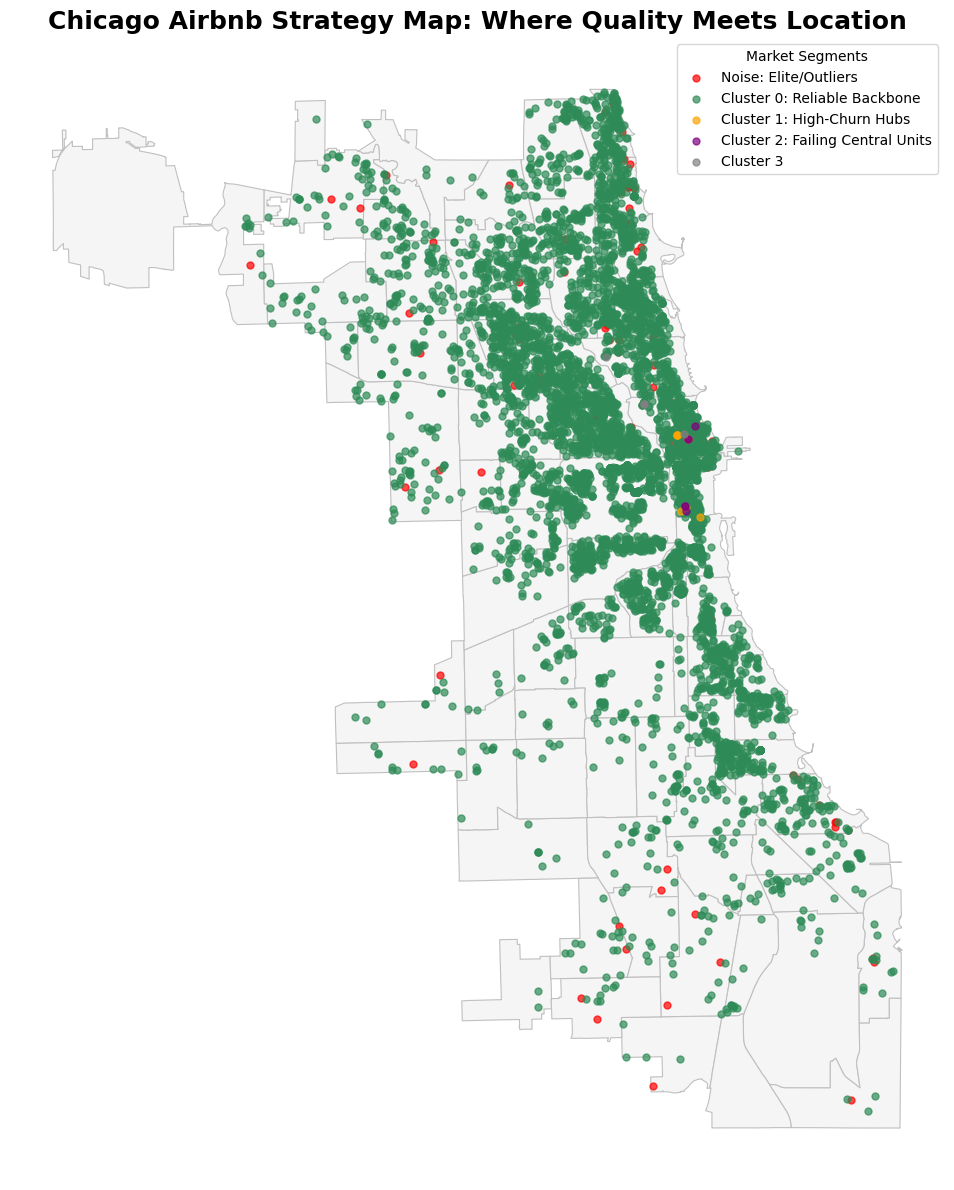

In [12]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 讀取座標數據
df_coords = pd.read_csv('listings.csv',
                        usecols=['id', 'latitude', 'longitude'],
                        lineterminator='\n',
                        low_memory=False)
df_coords.rename(columns={'id': 'listing_id'}, inplace=True)

# 2. 檢查目前 df 是否已經有經緯度，避免合併衝突
if 'latitude' in df.columns or 'longitude' in df.columns:
    # 如果已經有了，就不用再合併，直接用原本的
    df_map = df.copy()
    print("✅ 使用原始資料中的經緯度欄位")
else:
    # 如果沒有，才執行合併
    df_map = pd.merge(df, df_coords, on='listing_id', how='left')
    print("✅ 已從 listings.csv 成功合併座標數據")

# 3. 讀取芝加哥行政區劃 GeoJSON
chicago_map = gpd.read_file('neighbourhoods.geojson')

# 4. 強制處理可能出現的 _x, _y 命名衝突
# 如果合併後產生了 longitude_x，我們把它修正回來
if 'longitude_y' in df_map.columns:
    df_map['longitude'] = df_map['longitude_y']
    df_map['latitude'] = df_map['latitude_y']
elif 'longitude_x' in df_map.columns:
    df_map['longitude'] = df_map['longitude_x']
    df_map['latitude'] = df_map['latitude_x']

# 5. 轉換為 GeoDataFrame (改用中括號存取，更安全)
gdf_points = gpd.GeoDataFrame(
    df_map,
    geometry=gpd.points_from_xy(df_map['longitude'], df_map['latitude']),
    crs="EPSG:4326"
)

# 6. 繪圖邏輯 (排除經緯度缺失的點)
gdf_points = gdf_points.dropna(subset=['latitude', 'longitude'])

fig, ax = plt.subplots(figsize=(15, 12))
chicago_map.plot(ax=ax, color='whitesmoke', edgecolor='silver', linewidth=0.8)

# 定義顏色：Cluster 0, 1, 2 與 Noise (-1)
# 我們之前分析 Cluster 1 是市中心雷房，Cluster 0 是穩定模範生，Cluster 2 是崩潰中央雷房
palette = {0: 'seagreen', 1: 'orange', 2: 'purple', -1: 'red'}
labels = {0: 'Cluster 0: Reliable Backbone',
          1: 'Cluster 1: High-Churn Hubs',
          2: 'Cluster 2: Failing Central Units',
          -1: 'Noise: Elite/Outliers'}

for cluster_id in sorted(df_map['DBSCAN_Cluster'].unique()):
    gdf_points[gdf_points['DBSCAN_Cluster'] == cluster_id].plot(
        ax=ax,
        color=palette.get(cluster_id, 'grey'),
        marker='o',
        markersize=25,
        label=labels.get(cluster_id, f"Cluster {cluster_id}"),
        alpha=0.7
    )

plt.title('Chicago Airbnb Strategy Map: Where Quality Meets Location', fontsize=18, fontweight='bold')
plt.legend(title="Market Segments", fontsize=10)
ax.set_axis_off()

plt.tight_layout()
plt.show()

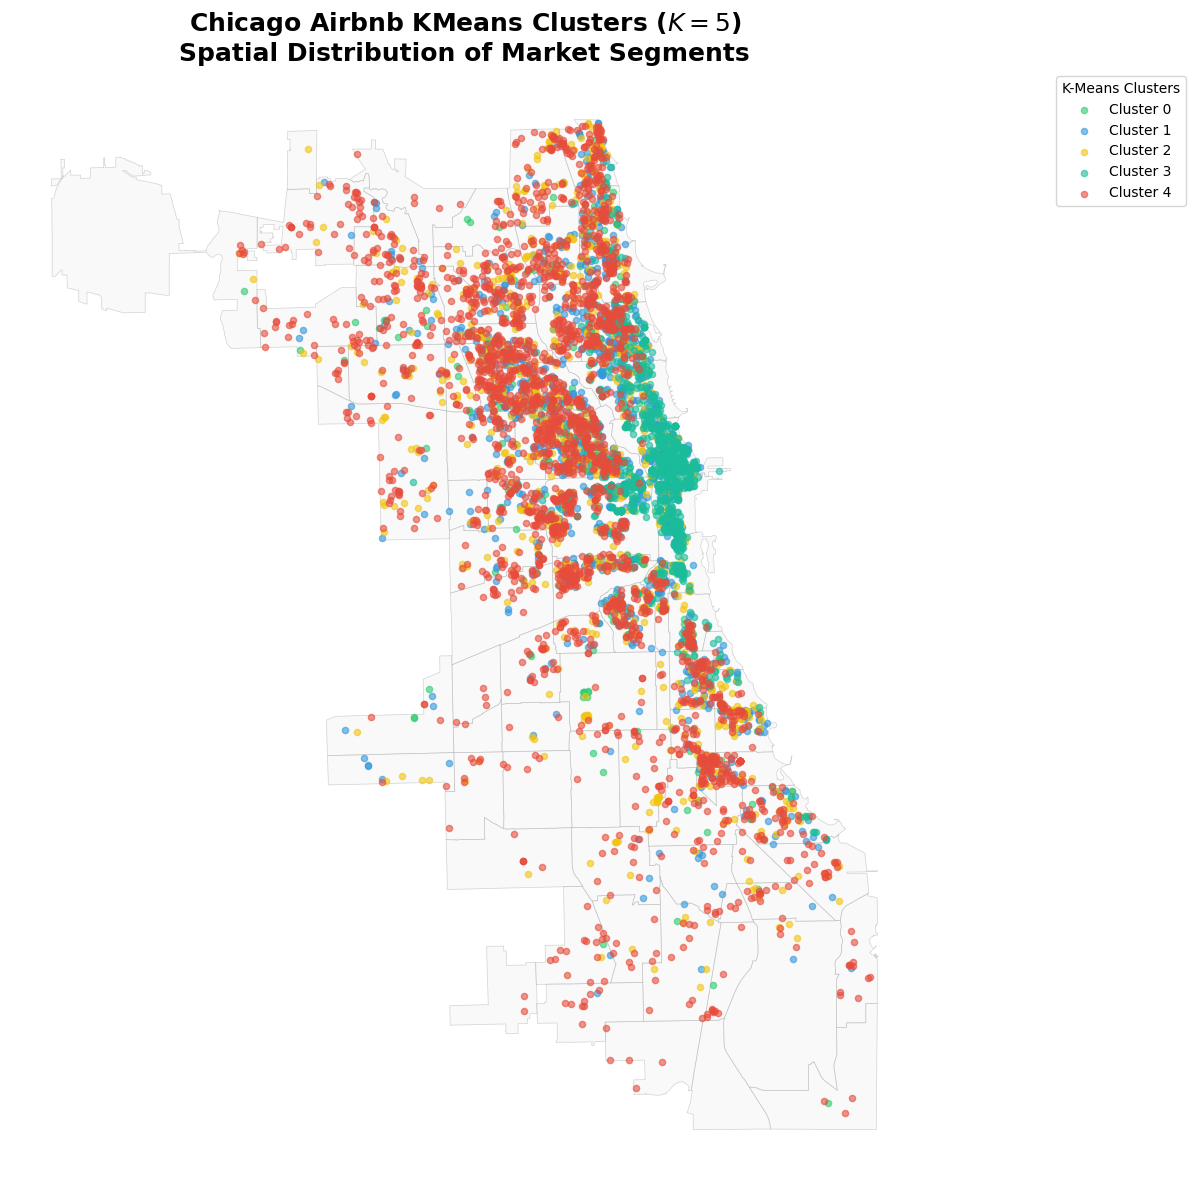

In [13]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 讀取座標數據
# 確保路徑與你的環境一致
df_coords = pd.read_csv('listings.csv', usecols=['id', 'latitude', 'longitude'])
df_coords.rename(columns={'id': 'listing_id'}, inplace=True)

# 2. 合併座標 (確保 listing_id 類型一致)
df['listing_id'] = df['listing_id'].astype(int)
df_coords['listing_id'] = df_coords['listing_id'].astype(int)

# 檢查是否已有經緯度，若無則合併
if 'latitude' not in df.columns:
    df_kmeans_map = pd.merge(df, df_coords, on='listing_id', how='left')
else:
    df_kmeans_map = df.copy()

# 3. 讀取地理圖資
chicago_map = gpd.read_file('neighbourhoods.geojson')

# 4. 轉換為 GeoDataFrame (使用安全的中括號存取)
# 同時過濾掉沒有座標的資料
df_kmeans_map = df_kmeans_map.dropna(subset=['latitude', 'longitude'])

gdf_kmeans = gpd.GeoDataFrame(
    df_kmeans_map,
    geometry=gpd.points_from_xy(df_kmeans_map['longitude'], df_kmeans_map['latitude']),
    crs="EPSG:4326"
)

# 5. 設定繪圖參數
fig, ax = plt.subplots(figsize=(15, 12))

# 畫出芝加哥底圖
chicago_map.plot(ax=ax, color='whitesmoke', edgecolor='darkgrey', linewidth=0.5, alpha=0.5)

# 定義 K-Means 的 5 個分群顏色與意義 (根據之前的 profile)
# Cluster 4: 績效與品質堪憂 (評分 2.55) -> 紅色
# Cluster 2: 高價值黃金型 -> 金色/黃色
# Cluster 1 & 3: 中堅穩定型 -> 藍色/青色
# Cluster 0: 平價穩定型 -> 綠色
palette = {
    4: '#e74c3c', # 紅色 (Problematic)
    2: '#f1c40f', # 黃色 (High Revenue)
    1: '#3498db', # 藍色 (Solid A)
    3: '#1abc9c', # 青色 (Solid B)
    0: '#2ecc71'  # 綠色 (Value)
}

# 6. 依序畫出各個分群
for cluster_id in sorted(df_kmeans_map['Final_Integrated_Cluster'].unique()):
    gdf_kmeans[gdf_kmeans['Final_Integrated_Cluster'] == cluster_id].plot(
        ax=ax,
        color=palette.get(cluster_id, 'grey'),
        marker='o',
        markersize=20,
        label=f'Cluster {cluster_id}',
        alpha=0.6
    )

# 7. 優化視覺細節
plt.title('Chicago Airbnb KMeans Clusters ($K=5$)\nSpatial Distribution of Market Segments', fontsize=18, fontweight='bold')
plt.legend(title="K-Means Clusters", loc='upper right', bbox_to_anchor=(1.3, 1))
ax.set_axis_off()

plt.tight_layout()
plt.show()

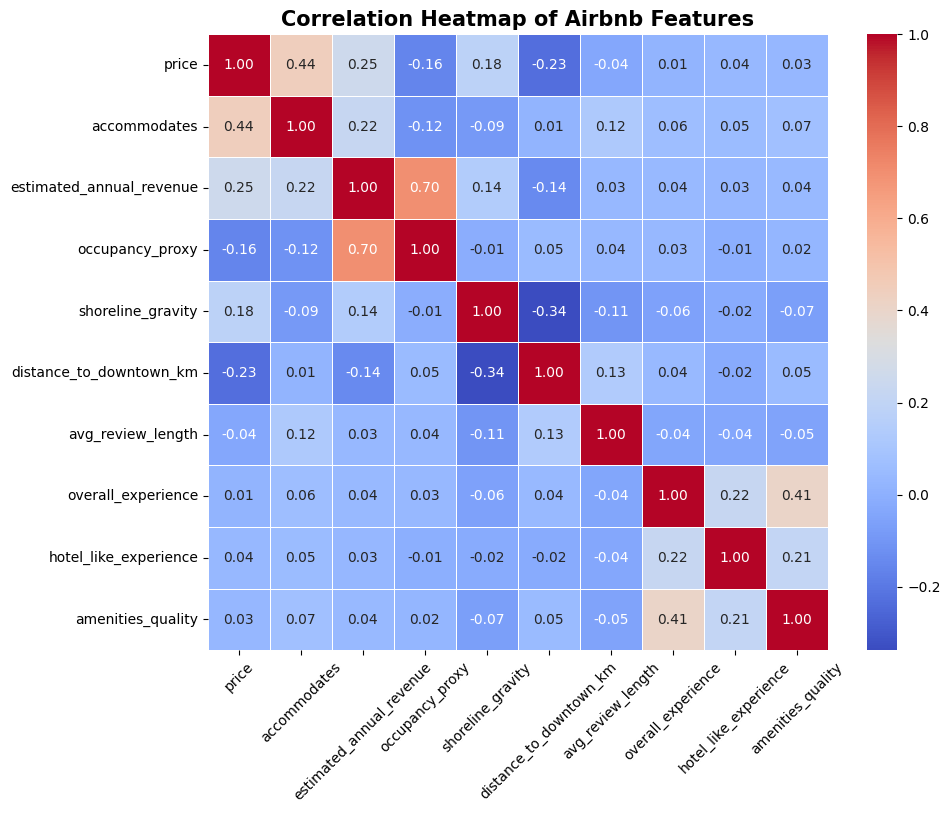

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 計算相關係數矩陣
selected_features = [
    'price', 'accommodates',
    'estimated_annual_revenue', 'occupancy_proxy',
    'shoreline_gravity', 'distance_to_downtown_km',
    'avg_review_length', 'overall_experience',
    'hotel_like_experience', 'amenities_quality'
]

corr_matrix = df[selected_features].corr()

# 2. 繪製 Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Airbnb Features', fontsize=15, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

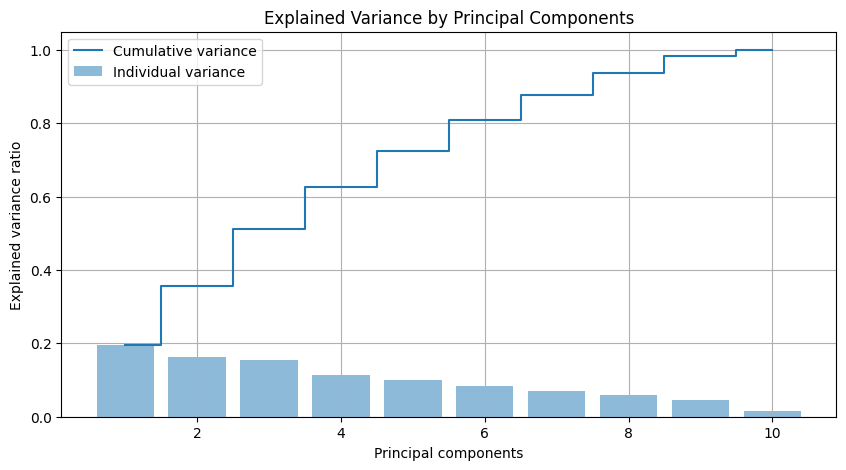

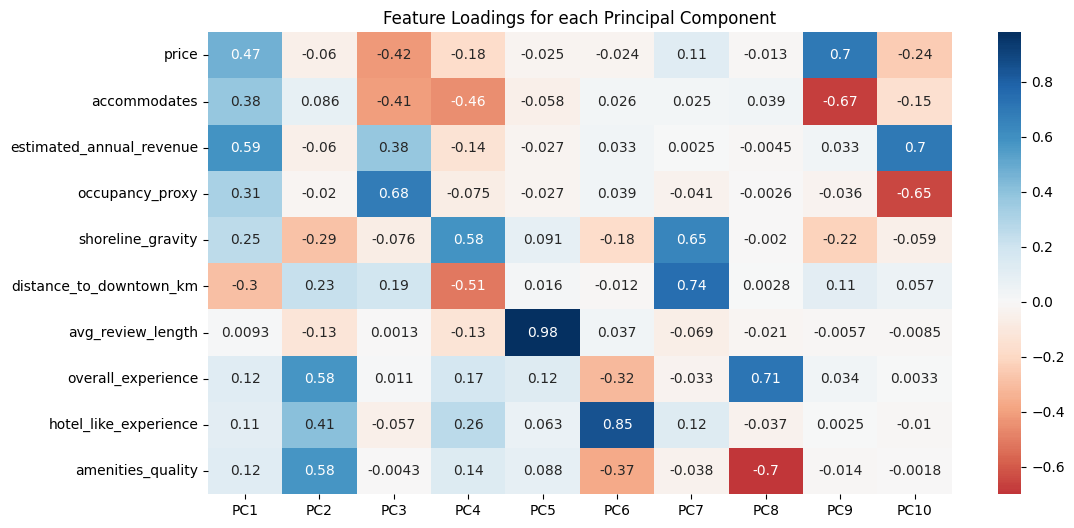

前兩個主成分 (PC1+PC2) 解釋了 35.72% 的原始數據變異量


In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 準備數據與標準化 (PCA 對縮放極其敏感)
# 假設 selected_features 已經定義過
X = df[selected_features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. 執行 PCA
# 我們先不限制成分數量，看全部 8 個成分的貢獻度
pca = PCA()
pca_data = pca.fit_transform(X_scaled)

# 3. 繪製「解釋變異量」圖 (Scree Plot)
# 這能告訴你：前幾個成分就能代表原本 80% 的資訊？
plt.figure(figsize=(10, 5))
exp_var_cum = np.cumsum(pca.explained_variance_ratio_)
plt.bar(range(1, 11), pca.explained_variance_ratio_, alpha=0.5, align='center', label='Individual variance')
plt.step(range(1, 11), exp_var_cum, where='mid', label='Cumulative variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.title('Explained Variance by Principal Components')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# 4. 繪製「特徵載荷熱點圖 (Loading Heatmap)」
# 💡 這張圖最重要！它告訴你每個 PC (主成分) 代表什麼意義
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(10)],
    index=selected_features
)

plt.figure(figsize=(12, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
plt.title('Feature Loadings for each Principal Component')
plt.show()

# 5. 輸出前兩個 PC 的解釋力
print(f"前兩個主成分 (PC1+PC2) 解釋了 {exp_var_cum[1]*100:.2f}% 的原始數據變異量")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ 成功處理 6006 筆資料


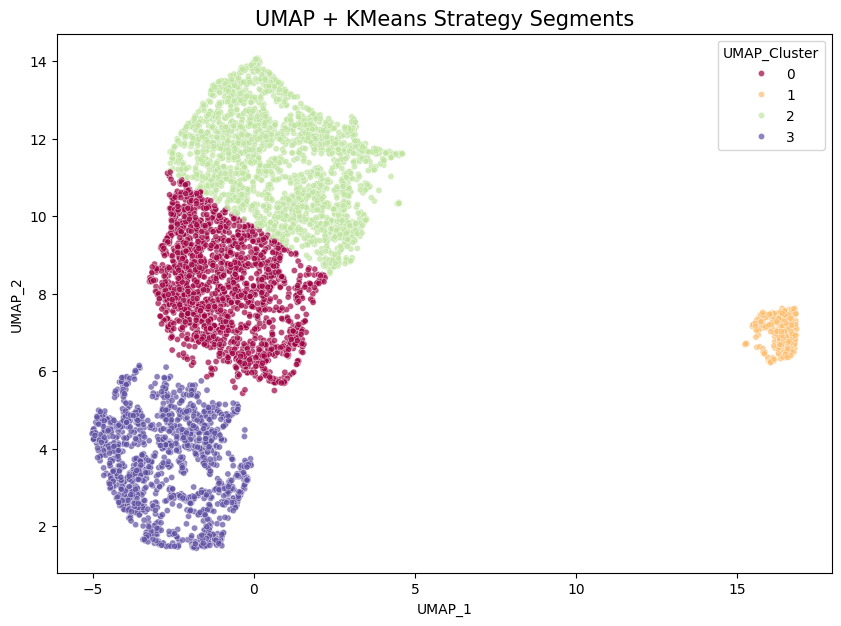

In [16]:
import umap
from sklearn.cluster import KMeans

# 1. 建立一個乾淨的副本，只包含沒有缺失值的資料
df_clean = df.dropna(subset=selected_features).copy()

# 2. 執行 UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
u_embedding = reducer.fit_transform(X_scaled) # X_scaled 必須是 (6042, 8)

# 3. 執行 KMeans
kmeans_u = KMeans(n_clusters=4, random_state=42)
u_labels = kmeans_u.fit_predict(u_embedding)

# 4. 安全地填回 df_clean (因為長度都是 6042)
df_clean['UMAP_Cluster'] = u_labels
df_clean['UMAP_1'] = u_embedding[:, 0]
df_clean['UMAP_2'] = u_embedding[:, 1]

# 💡 如果你一定要填回原始的 df，要用 index 對位：
# df.loc[df_clean.index, 'UMAP_Cluster'] = u_labels

print(f"✅ 成功處理 {len(df_clean)} 筆資料")

# 5. 繪圖
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=df_clean['UMAP_1'], y=df_clean['UMAP_2'],
    hue=df_clean['UMAP_Cluster'], palette='Spectral', s=20, alpha=0.7
)
plt.title('UMAP + KMeans Strategy Segments', fontsize=15)
plt.show()

In [17]:
from sklearn.metrics import silhouette_score

# 1. 在 UMAP 降維後的 2D 空間計算分數
# 這代表在圖表上看到的「成團程度」
score_umap_2d = silhouette_score(u_embedding, u_labels)

# 2. 在原始的 8 維標準化空間計算分數 (使用 UMAP 分出來的標籤)
# 這最重要！代表這些分群在原始數據中是否真的分得開
score_original_8d = silhouette_score(X_scaled, u_labels)

print(f"📊 UMAP 空間 (2D) 輪廓分數: {score_umap_2d:.4f}")
print(f"📊 原始特徵 (8D) 輪廓分數: {score_original_8d:.4f}")

📊 UMAP 空間 (2D) 輪廓分數: 0.4698
📊 原始特徵 (8D) 輪廓分數: 0.1440


In [18]:
# 1. 計算 4 個 UMAP 集群的特徵平均值
umap_profile = df_clean.groupby('UMAP_Cluster')[selected_features].mean().round(2)

# 2. 顯示結果並排序 (以年收入為例)
print("--- UMAP + KMeans 4 大集群特徵解析 ---")
print(umap_profile.sort_values(by='estimated_annual_revenue', ascending=False))

# 3. 檢查各集群人數
print("\n--- 各集群房源數量 ---")
print(df_clean['UMAP_Cluster'].value_counts())

--- UMAP + KMeans 4 大集群特徵解析 ---
               price  accommodates  estimated_annual_revenue  occupancy_proxy  \
UMAP_Cluster                                                                    
0             165.08          4.48                  36573.93             0.63   
1             213.08          5.02                  22545.18             0.34   
3             163.99          4.00                  18596.29             0.33   
2             212.26          5.33                   8805.37             0.13   

              shoreline_gravity  distance_to_downtown_km  avg_review_length  \
UMAP_Cluster                                                                  
0                          0.38                     7.87             241.51   
1                          0.39                     6.93             232.58   
3                          0.43                     7.14             264.45   
2                          0.39                     7.35             237.94   

      

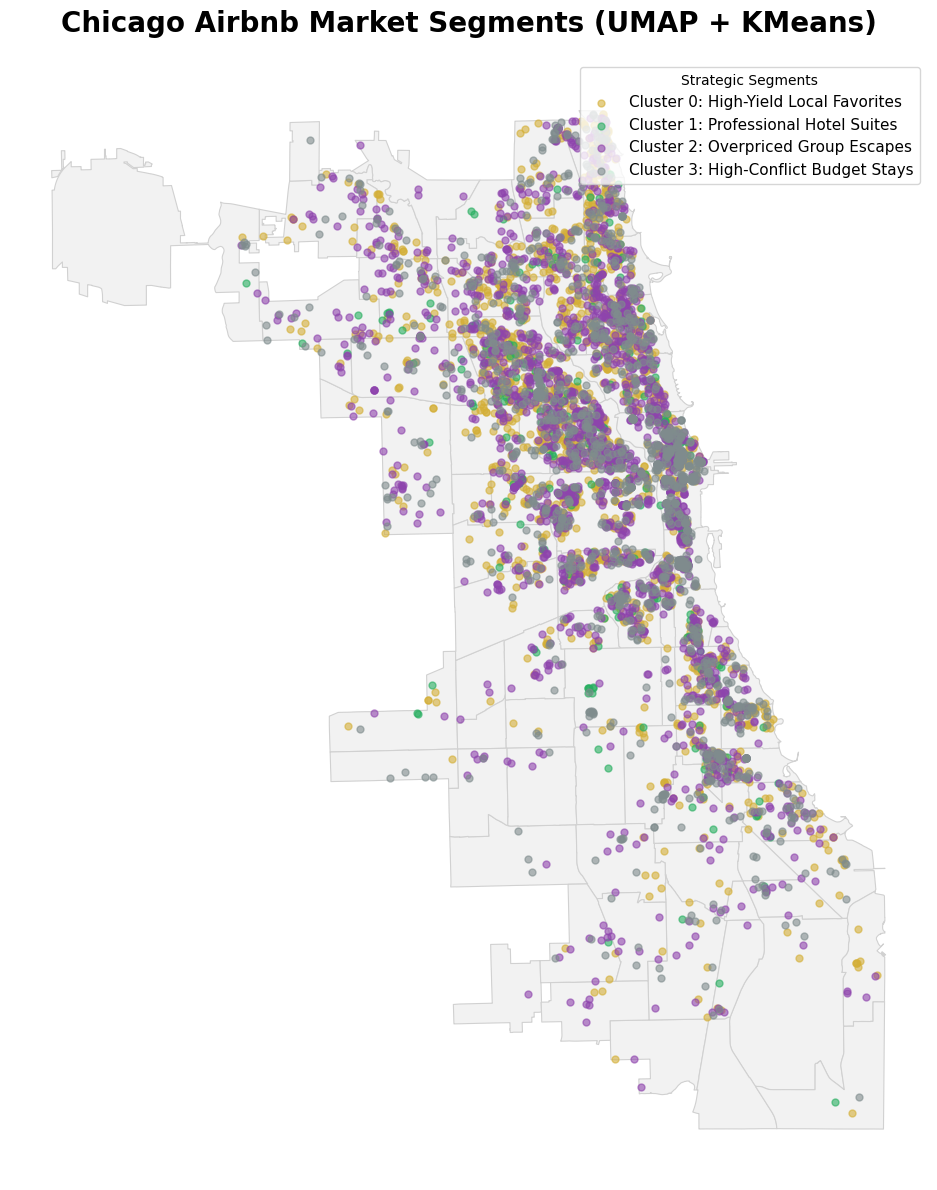

In [19]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 確保 ID 類型一致並合併座標
df_clean['listing_id'] = df_clean['listing_id'].astype(int)
df_coords = pd.read_csv('listings.csv', usecols=['id', 'latitude', 'longitude'])
df_coords.rename(columns={'id': 'listing_id'}, inplace=True)
df_coords['listing_id'] = df_coords['listing_id'].astype(int)

df_map = pd.merge(df_clean, df_coords, on='listing_id', how='left')

# 2. 讀取芝加哥行政區劃 GeoJSON
chicago_map = gpd.read_file('neighbourhoods.geojson')

# 3. 轉換為 GeoDataFrame
# 這裡使用之前教你的安全欄位偵測
def get_col(df, target):
    for col in df.columns:
        if target in col.lower(): return col
    return None

lat_col = get_col(df_map, 'latitude')
lon_col = get_col(df_map, 'longitude')

gdf = gpd.GeoDataFrame(
    df_map,
    geometry=gpd.points_from_xy(df_map[lon_col], df_map[lat_col]),
    crs="EPSG:4326"
).dropna(subset=[lat_col, lon_col])

# 4. **重新定義標籤與顏色 (核心修復處)**
# 確保 0, 1, 2, 3 都有對應到
palette = {
    0: '#D4AF37', # 金色 高收益在地熱門房 (最高住房率與營收)
    1: '#27AE60', # 綠色 專業管理飯店型套房 (類飯店分數 0.99)
    2: '#8E44AD', # 紫色 定價過高的大型聚會房 (大空間、高單價但極低住房率)
    3: '#7F8C8D'  # 灰色 高爭議平價房 (體驗與設施極差、評論最長)
}

labels = {
    0: 'Cluster 0: High-Yield Local Favorites',
    1: 'Cluster 1: Professional Hotel Suites',
    2: 'Cluster 2: Overpriced Group Escapes',
    3: 'Cluster 3: High-Conflict Budget Stays'
}

# 5. 繪圖
fig, ax = plt.subplots(figsize=(15, 12))
chicago_map.plot(ax=ax, color='#f2f2f2', edgecolor='#d1d1d1', linewidth=0.8)

# 獲取資料中實際存在的集群編號
existing_clusters = sorted(df_map['UMAP_Cluster'].unique())

for cluster_id in existing_clusters:
    subset = gdf[gdf['UMAP_Cluster'] == cluster_id]
    # 使用 .get() 確保萬一有沒定義到的 ID 不會報錯
    ax_color = palette.get(cluster_id, '#333333')
    ax_label = labels.get(cluster_id, f'Cluster {cluster_id}')

    subset.plot(
        ax=ax,
        color=ax_color,
        marker='o',
        markersize=25,
        label=ax_label,
        alpha=0.6
    )

plt.title('Chicago Airbnb Market Segments (UMAP + KMeans)', fontsize=20, fontweight='bold', pad=20)
plt.legend(title="Strategic Segments", fontsize=11, loc='upper right')
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [26]:
%pip install hdbscan

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


✅ HDBSCAN 偵測到 3 個集群
🚨 偵測到 28 個噪點房源 (佔 0.47%)


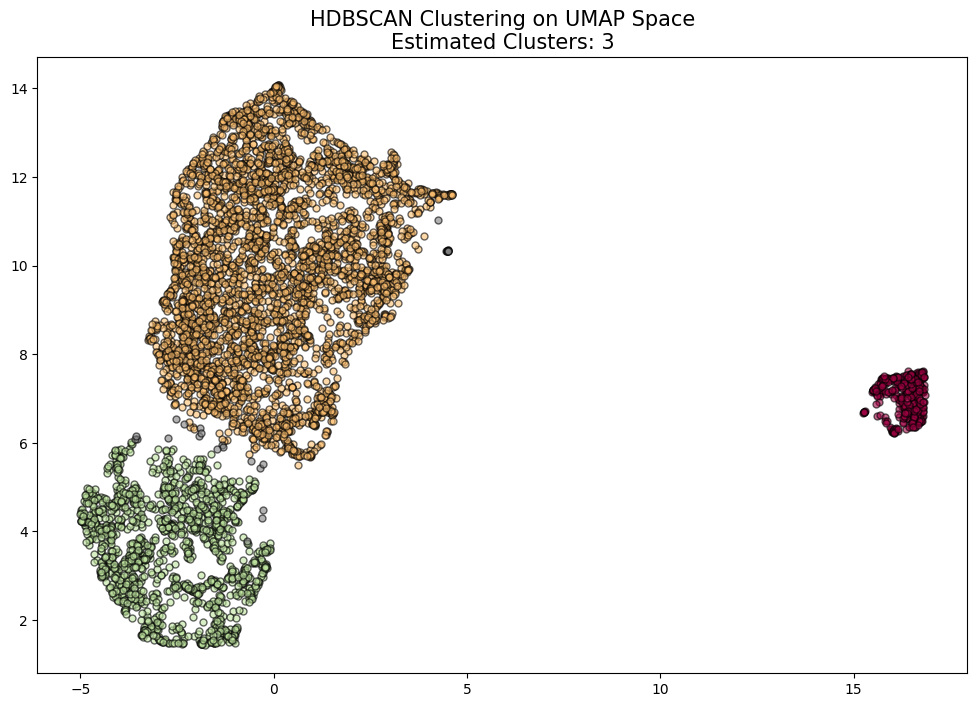

In [20]:
import hdbscan
import numpy as np

# 1. 使用之前的 UMAP 2D 嵌入 (u_embedding)
# 2. 執行 HDBSCAN
# min_cluster_size: 一個群體最少要有多少點？(可以設 30-50，依資料量調整)
# min_samples: 控制分群的保守程度，越大則越多點會被歸類為噪點
clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10, gen_min_span_tree=True)
hdbscan_labels = clusterer.fit_predict(u_embedding)

# 3. 把標籤存回 df_clean
df_clean['HDBSCAN_Cluster'] = hdbscan_labels

# 4. 計算分群數量 (排除 -1)
n_clusters_ = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise_ = list(hdbscan_labels).count(-1)

print(f"✅ HDBSCAN 偵測到 {n_clusters_} 個集群")
print(f"🚨 偵測到 {n_noise_} 個噪點房源 (佔 {n_noise_/len(df_clean)*100:.2f}%)")

# 5. 視覺化
plt.figure(figsize=(12, 8))
# 噪點用灰色表示，其他群體用顏色區分
unique_labels = set(hdbscan_labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0.5, 0.5, 0.5, 1] # 灰色

    class_member_mask = (hdbscan_labels == k)
    xy = u_embedding[class_member_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=5, alpha=0.6)

plt.title(f'HDBSCAN Clustering on UMAP Space\nEstimated Clusters: {n_clusters_}', fontsize=15)
plt.show()

In [21]:
# 查看每個集群的人數
print(df_clean['HDBSCAN_Cluster'].value_counts().head(32))

HDBSCAN_Cluster
 1    4166
 2    1460
 0     352
-1      28
Name: count, dtype: int64


In [22]:
from sklearn.metrics import silhouette_score

# 1. 建立遮罩，排除標籤為 -1 (噪點) 的資料
mask = hdbscan_labels != -1
u_filtered = u_embedding[mask]
X_filtered = X_scaled[mask]
labels_filtered = hdbscan_labels[mask]

# 2. 計算分數
score_hdbscan_2d = silhouette_score(u_filtered, labels_filtered)
score_hdbscan_8d = silhouette_score(X_filtered, labels_filtered)

print(f"📊 [HDBSCAN] UMAP 空間 (2D) 輪廓分數: {score_hdbscan_2d:.4f}")
print(f"📊 [HDBSCAN] 原始特徵 (8D) 輪廓分數: {score_hdbscan_8d:.4f}")
print(f"📈 參與分群的房源比例: {(len(labels_filtered)/len(df_clean))*100:.2f}%")

📊 [HDBSCAN] UMAP 空間 (2D) 輪廓分數: 0.5604
📊 [HDBSCAN] 原始特徵 (8D) 輪廓分數: 0.1692
📈 參與分群的房源比例: 99.53%


In [23]:
import hdbscan

# 1. 執行大尺度 HDBSCAN
# min_cluster_size=150: 確保每個群體至少有約 2.5% 的市場份額
# cluster_selection_method='eom': (Excess of Objects) 這是最穩定的合併演算法
clusterer_final = hdbscan.HDBSCAN(
    min_cluster_size=150,
    min_samples=15,
    prediction_data=True,
    gen_min_span_tree=True
)
hdb_labels_macro = clusterer_final.fit_predict(u_embedding)

# 2. 統計結果
n_clusters_macro = len(set(hdb_labels_macro)) - (1 if -1 in hdb_labels_macro else 0)
noise_count = list(hdb_labels_macro).count(-1)

print(f"✅ 成功收斂至 {n_clusters_macro} 個核心集群")
print(f"🚨 初始噪點比例: {(noise_count/len(df_clean))*100:.2f}%")

✅ 成功收斂至 2 個核心集群
🚨 初始噪點比例: 0.00%


In [24]:
# 1. 計算每個點屬於各集群的概率 (Membership Strengths)
soft_clusters = hdbscan.all_points_membership_vectors(clusterer_final)

# 2. 將噪點 (-1) 強制分配給概率最高的集群
# 這樣我們就能達到 100% 的分類覆蓋
final_strategic_labels = [np.argmax(x) for x in soft_clusters]
df_clean['Strategic_Cluster'] = final_strategic_labels

print("🎉 噪點已全數分配完成，實現 100% 市場覆蓋！")

🎉 噪點已全數分配完成，實現 100% 市場覆蓋！


In [25]:
# 計算 5-6 個大集群的平均特徵
strategic_profile = df_clean.groupby('Strategic_Cluster')[selected_features].mean().round(2)
strategic_profile['Count'] = df_clean['Strategic_Cluster'].value_counts()

# 根據營收排序，讓讀者一眼看出市場階層
strategic_profile = strategic_profile.sort_values(by='estimated_annual_revenue', ascending=False)
print("--- Chicago Airbnb 戰略集群分析 (Final Version) ---")
display(strategic_profile)

--- Chicago Airbnb 戰略集群分析 (Final Version) ---


,price,accommodates,estimated_annual_revenue,occupancy_proxy,shoreline_gravity,distance_to_downtown_km,avg_review_length,overall_experience,hotel_like_experience,amenities_quality,Count
Strategic_Cluster,,,,,,,,,,,
0,213.08,5.02,22545.18,0.34,0.39,6.93,232.58,0.58,0.99,0.49,352
1,183.57,4.69,20863.87,0.35,0.40,7.47,246.04,0.43,0.08,0.38,5654


✅ 成功定位地理欄位: latitude, longitude


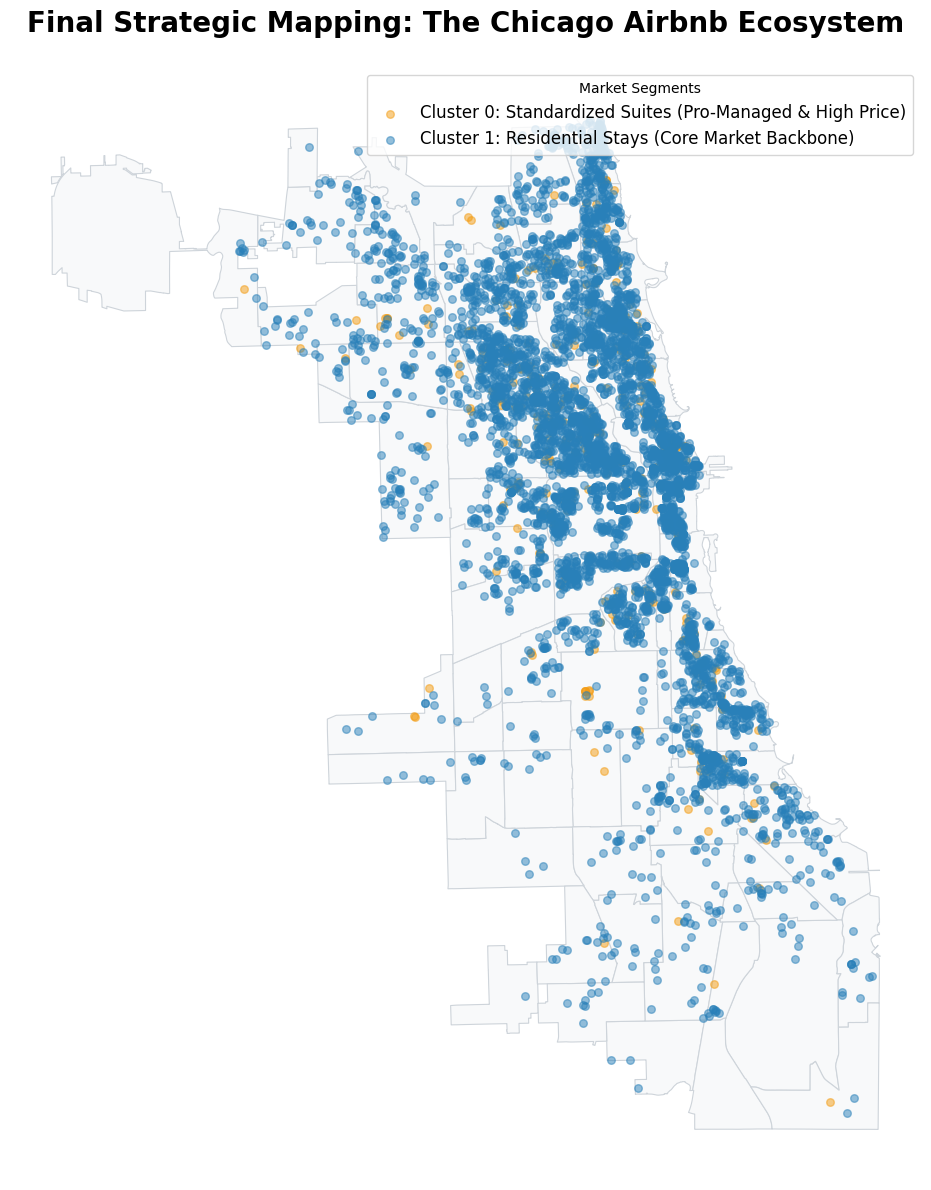

In [26]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. 確保 ID 類型一致並合併
df_clean['listing_id'] = df_clean['listing_id'].astype(int)
df_coords = pd.read_csv('listings.csv', usecols=['id', 'latitude', 'longitude'])
df_coords.rename(columns={'id': 'listing_id'}, inplace=True)
df_coords['listing_id'] = df_coords['listing_id'].astype(int)

# 執行合併 (使用 suffixes 確保我們能追蹤來源)
df_final_map = pd.merge(df_clean, df_coords, on='listing_id', how='left', suffixes=('_old', ''))

# 2. 【核心修復】自動偵測欄位名稱
def find_geo_col(df, target):
    # 優先找精確匹配，再找包含目標字串且不帶 '_old' 的欄位
    cols = df.columns.tolist()
    if target in cols: return target
    for c in cols:
        if target in c.lower() and '_old' not in c:
            return c
    return None

lat_key = find_geo_col(df_final_map, 'latitude')
lon_key = find_geo_col(df_final_map, 'longitude')

if not lat_key or not lon_key:
    raise KeyError(f"在欄位中找不到經緯度！目前的欄位有: {df_final_map.columns.tolist()}")

print(f"✅ 成功定位地理欄位: {lat_key}, {lon_key}")

# 3. 讀取芝加哥行政區劃
chicago_map = gpd.read_file('neighbourhoods.geojson')

# 4. 轉換為 GeoDataFrame
gdf_final = gpd.GeoDataFrame(
    df_final_map,
    geometry=gpd.points_from_xy(df_final_map[lon_key], df_final_map[lat_key]),
    crs="EPSG:4326"
).dropna(subset=[lat_key, lon_key])

# 5. 定義戰略色彩與標籤
palette = {
    0: '#F39C12', # Gold: 用亮金色突顯數量稀少 (352間) 但高單價的「頂級飯店套房」
    1: '#2980B9'  # Blue: 用沉穩的藍色代表數量龐大 (5654間) 的「核心在地住宅」
}

labels = {
    0: 'Cluster 0: Standardized Suites (Pro-Managed & High Price)',
    1: 'Cluster 1: Residential Stays (Core Market Backbone)'
}

# 6. 繪圖
fig, ax = plt.subplots(figsize=(15, 12))
chicago_map.plot(ax=ax, color='#f8f9fa', edgecolor='#ced4da', linewidth=0.8)

for cid in sorted(df_final_map['Strategic_Cluster'].unique()):
    subset = gdf_final[gdf_final['Strategic_Cluster'] == cid]
    subset.plot(
        ax=ax,
        color=palette.get(cid, '#333333'),
        marker='o',
        markersize=30,
        label=labels.get(cid, f'Cluster {cid}'),
        alpha=0.5
    )

plt.title('Final Strategic Mapping: The Chicago Airbnb Ecosystem', fontsize=20, fontweight='bold', pad=25)
plt.legend(title="Market Segments", fontsize=12, loc='upper right')
ax.set_axis_off()

plt.tight_layout()
plt.show()

📊 [Final 2-Cluster] UMAP 空間 (2D) 輪廓分數: 0.7384
📊 [Final 2-Cluster] 原始特徵 (8D) 輪廓分數: 0.2716


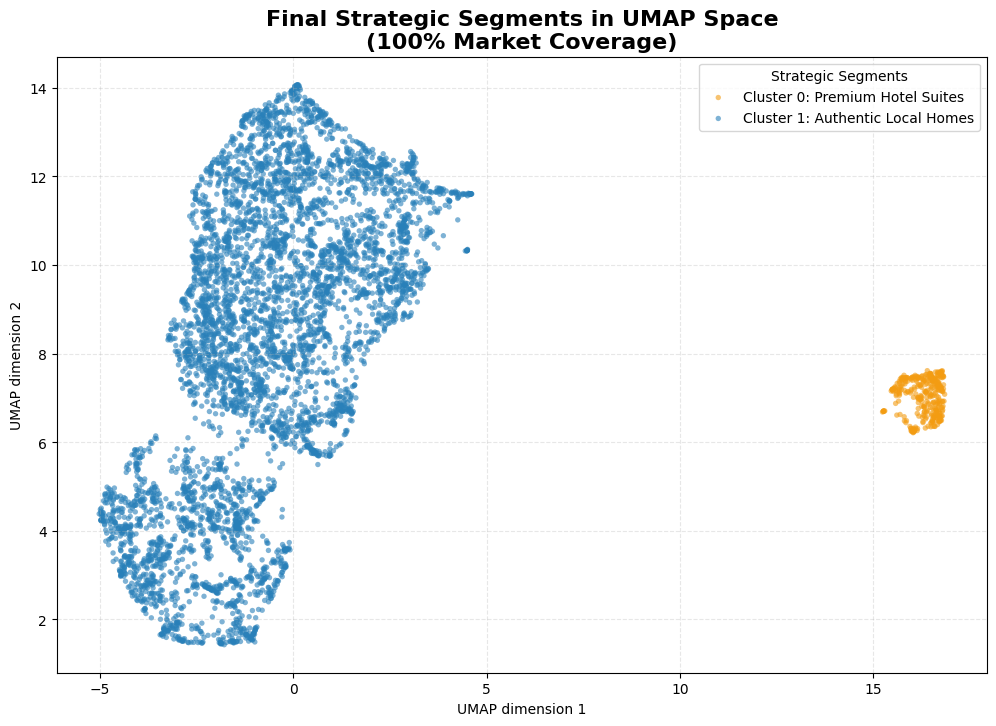

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

# 1. 計算最終 3 集群的輪廓分數 (100% 數據)
# 注意：這裡不再排除 -1，因為我們已經完成全數分配
final_labels = df_clean['Strategic_Cluster']

score_final_2d = silhouette_score(u_embedding, final_labels)
score_final_8d = silhouette_score(X_scaled, final_labels)

print(f"📊 [Final 2-Cluster] UMAP 空間 (2D) 輪廓分數: {score_final_2d:.4f}")
print(f"📊 [Final 2-Cluster] 原始特徵 (8D) 輪廓分數: {score_final_8d:.4f}")

# 2. 定義對應地圖的顏色
palette = {
    0: '#F39C12', # Gold (代表頂級飯店套房)
    1: '#2980B9'  # Blue (代表核心在地住宅)
}

labels_map = {
    0: 'Cluster 0: Premium Hotel Suites',
    1: 'Cluster 1: Authentic Local Homes'
}

# 3. 繪製 UMAP 2D 散佈圖
plt.figure(figsize=(12, 8))

for cid in sorted(final_labels.unique()):
    mask = (final_labels == cid)
    plt.scatter(
        u_embedding[mask, 0], u_embedding[mask, 1],
        c=palette[cid],
        label=labels_map[cid],
        s=15, alpha=0.6, edgecolors='none'
    )

plt.title('Final Strategic Segments in UMAP Space\n(100% Market Coverage)', fontsize=16, fontweight='bold')
plt.xlabel('UMAP dimension 1')
plt.ylabel('UMAP dimension 2')
plt.legend(title="Strategic Segments", loc='best')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [28]:
# 1. 獲取 HDBSCAN 的相對有效性指標 (Relative Validity Index)
# 這就是該演算法內建的 DBCV 變體分數
validity_score = clusterer_final.relative_validity_

print(f"📊 [DBCV] 密度連通性有效分數: {validity_score:.4f}")

# 2. 獲取每個點的穩定性 (Persistence)
# 這可以幫你找出哪些房源是「非常穩定地屬於某一群」
cluster_persistence = clusterer_final.probabilities_
avg_persistence = cluster_persistence.mean()

print(f"📈 樣本平均歸屬穩定度: {avg_persistence:.4f}")

📊 [DBCV] 密度連通性有效分數: 0.9098
📈 樣本平均歸屬穩定度: 0.9927
